In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

load and read data

In [24]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")

OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

CT_PATH = DATA_DIR / "ct_018.png"
MRI_PATH = DATA_DIR / "mri_018.png"

In [25]:
ct = cv2.imread(str(CT_PATH), cv2.IMREAD_GRAYSCALE)

mri = cv2.imread(str(MRI_PATH), cv2.IMREAD_GRAYSCALE)

if ct is None or mri is None:
    raise FileNotFoundError("Could not load CT or MRI.")

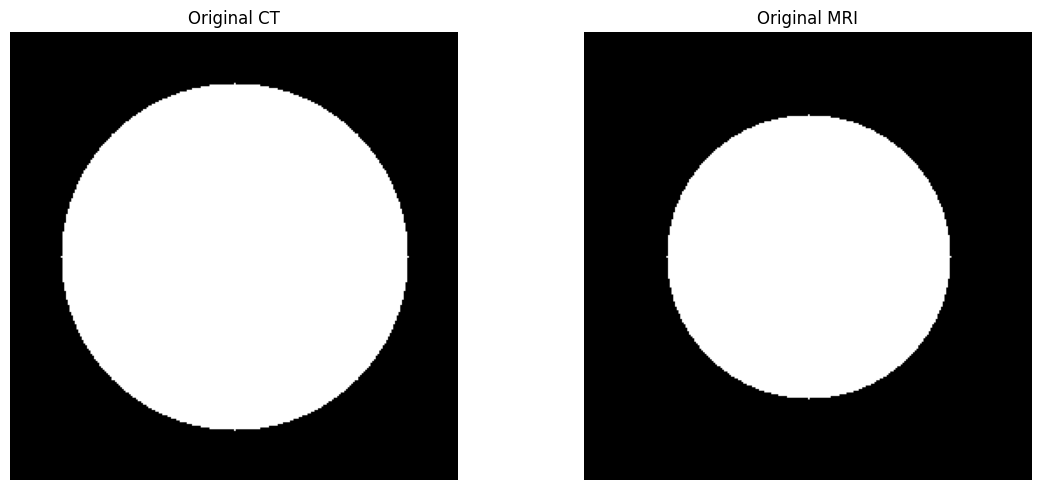

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ct, cmap="gray")
plt.title("Original CT")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mri, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.tight_layout()
plt.show()

resize if needed

In [27]:
if ct.shape != mri.shape:
    mri = cv2.resize(mri, (ct.shape[1], ct.shape[0]))

equalize

In [28]:
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)

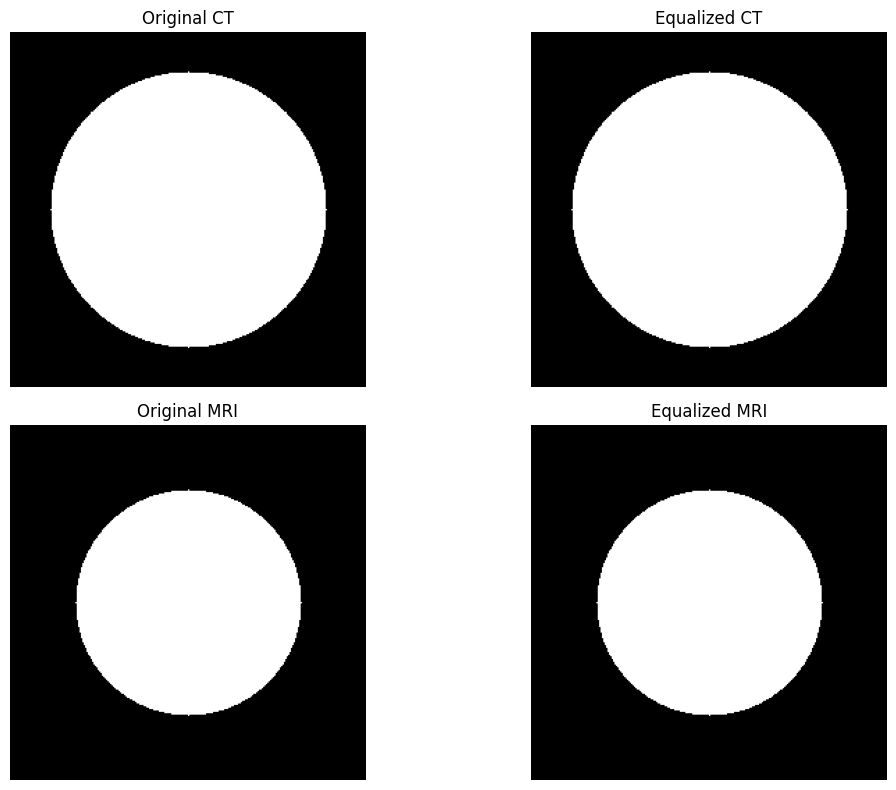

In [29]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(ct, cmap="gray")
plt.title("Original CT")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(ct_eq, cmap="gray")
plt.title("Equalized CT")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(mri, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(mri_eq, cmap="gray")
plt.title("Equalized MRI")
plt.axis("off")

plt.tight_layout()
plt.show()

color maps

In [30]:
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_JET)

mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_HOT)

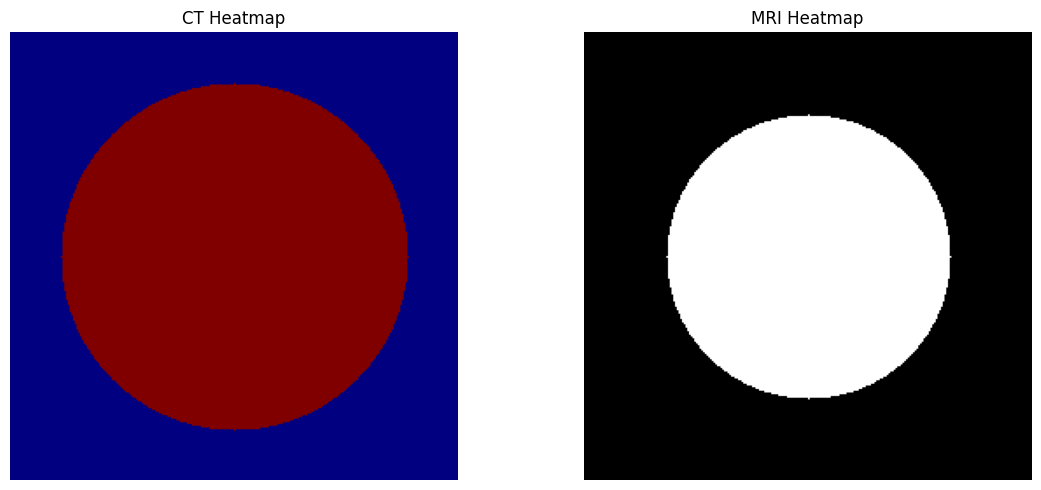

In [31]:
ct_color_rgb = cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)
mri_color_rgb = cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ct_color_rgb)
plt.title("CT Heatmap")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mri_color_rgb)
plt.title("MRI Heatmap")
plt.axis("off")

plt.tight_layout()
plt.show()

Fusion

In [32]:
alpha = 0.7
beta = 0.3

fused = cv2.addWeighted(ct_color, alpha, mri_color, beta, 0)

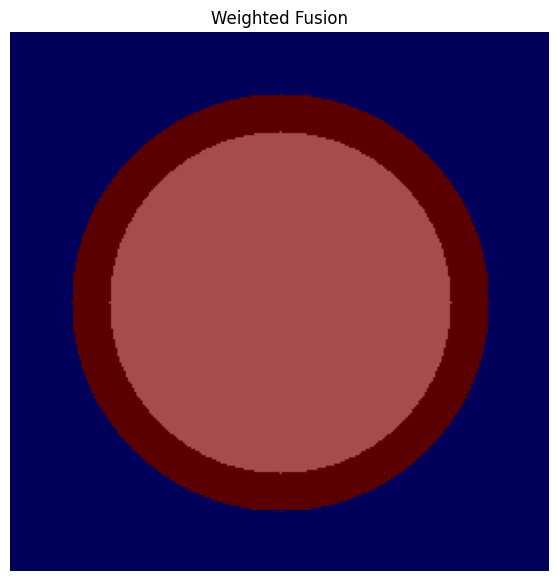

In [33]:
fused_rgb = cv2.cvtColor(fused, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 7))

plt.imshow(fused_rgb)
plt.title("Weighted Fusion")
plt.axis("off")

plt.show()

Log function

In [34]:
def log_transform(image):
  image_float = image.astype(np.float32)

  c = 255.0 / np.log1p(np.max(image_float))

  result = (c * np.log1p(image_float))

  return np.clip(result, 0, 255).astype(np.uint8)

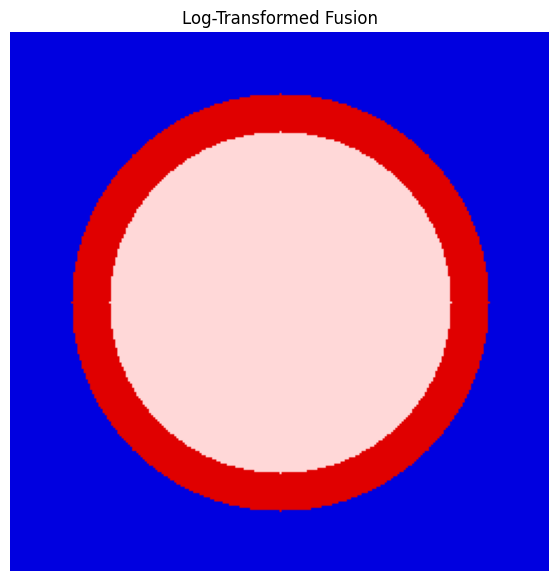

In [35]:
fused_log = log_transform(fused)

fused_log_rgb = cv2.cvtColor(fused_log, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 7))

plt.imshow(fused_log_rgb)
plt.title("Log-Transformed Fusion")
plt.axis("off")

plt.show()

Gamma Function

In [36]:
def gamma_transform(image, gamma=0.8):
  normalized = (image.astype(np.float32) / 255.0)

  result = np.power(normalized, gamma)

  result *= 255.0

  return np.clip(result, 0, 255).astype(np.uint8)

applied

In [37]:
fused_gamma= gamma_transform(fused, gamma=0.8)

comparsion

In [38]:
ct_color_rgb = cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)

mri_color_rgb = cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)

fused_rgb = cv2.cvtColor(fused, cv2.COLOR_BGR2RGB)

fused_log_rgb = cv2.cvtColor(fused_log, cv2.COLOR_BGR2RGB)

fused_gamma_rgb = cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB)

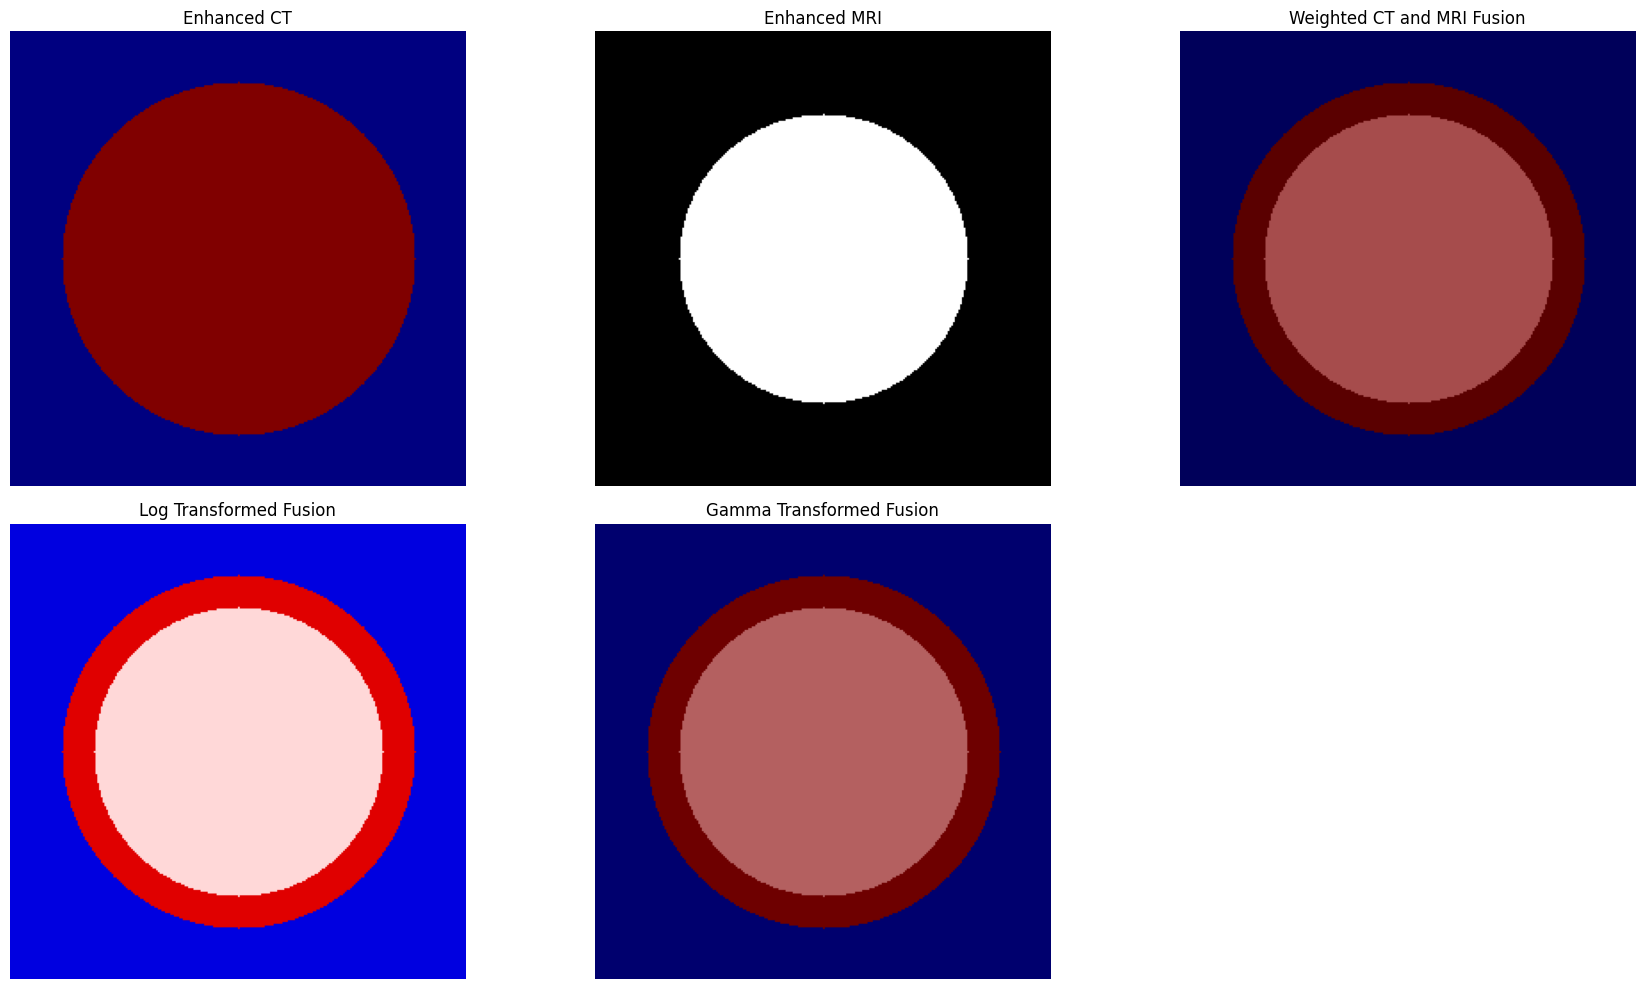

In [39]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(ct_color_rgb)
plt.title("Enhanced CT")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mri_color_rgb)
plt.title("Enhanced MRI")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(fused_rgb)
plt.title("Weighted CT and MRI Fusion")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(fused_log_rgb)
plt.title("Log Transformed Fusion")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(fused_gamma_rgb)
plt.title("Gamma Transformed Fusion")
plt.axis("off")

plt.tight_layout()
plt.show()

quantitative comparision

In [40]:
def image_stats(name, image):
    print(name)
    print("Min:", image.min())
    print("Max:", image.max())
    print("Mean:", image.mean())
    print("Std:", image.std())
    print()

In [41]:
image_stats("CT", ct_eq)
image_stats("MRI", mri_eq)
image_stats("Fused", fused)

CT
Min: 0
Max: 255
Mean: 119.67521667480469
Std: 127.25966668946506

MRI
Min: 0
Max: 255
Mean: 80.12718200683594
Std: 118.37257332417232

Fused
Min: 0
Max: 166
Mean: 53.88104248046875
Std: 55.17839285953943



In [42]:
cv2.imwrite(str(OUTPUT_DIR / "ct_equalized.png"), ct_eq)

cv2.imwrite(str(OUTPUT_DIR / "mri_equalized.png"), mri_eq)

cv2.imwrite(str(OUTPUT_DIR / "ct_heatmap.png"), ct_color)

cv2.imwrite(str(OUTPUT_DIR / "mri_heatmap.png"), mri_color)

cv2.imwrite(str(OUTPUT_DIR / "weighted_fusion.png"), fused)

cv2.imwrite(str(OUTPUT_DIR / "fusion_log.png"), fused_log)

cv2.imwrite(str(OUTPUT_DIR / "fusion_gamma.png"), fused_gamma)

True